# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [1]:
import sys

import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(100, None, None, model, testing=True)

epoch 0; train: loss 913.9550170898438; val: loss 899.7413330078125
epoch 1; train: loss 613.0079956054688; val: loss 865.0673828125
epoch 2; train: loss 464.6455383300781; val: loss 812.2291870117188
epoch 3; train: loss 359.8642578125; val: loss 747.0593872070312
epoch 4; train: loss 283.43194580078125; val: loss 684.419921875
epoch 5; train: loss 225.3441925048828; val: loss 634.6126708984375
epoch 6; train: loss 180.44613647460938; val: loss 595.10888671875
epoch 7; train: loss 147.02203369140625; val: loss 550.15478515625
epoch 8; train: loss 120.84736633300781; val: loss 495.317138671875
epoch 9; train: loss 99.7098388671875; val: loss 427.9407958984375
epoch 10; train: loss 84.46043395996094; val: loss 355.5940246582031
epoch 11; train: loss 72.7490005493164; val: loss 289.40350341796875
epoch 12; train: loss 63.44928741455078; val: loss 227.84422302246094
epoch 13; train: loss 55.91831970214844; val: loss 168.45193481445312
epoch 14; train: loss 49.788875579833984; val: loss 11

As can be seen above, the basic implementation of the training loop works, decreasing the loss significantly over the epochs. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [7]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")
img, ann = data[1]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

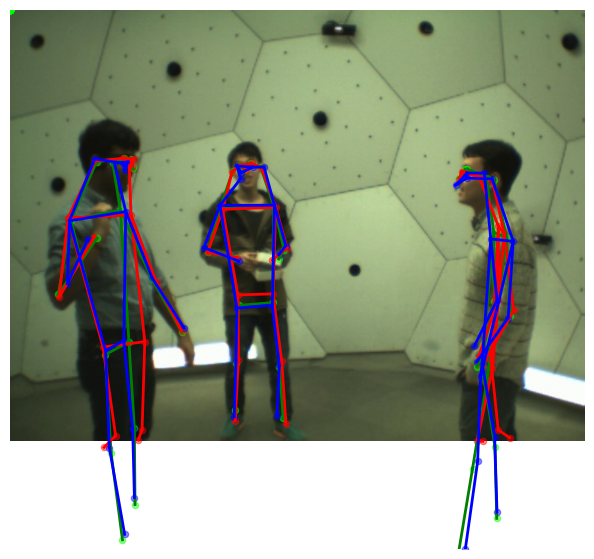

In [8]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.